### Mount Google Drive

This cell mounts your Google Drive to the Colab environment, allowing you to access files stored in your Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Unzip Dataset

This cell unzips the `crop_dataset.zip` file, located in your Google Drive, into the `/content/crop_dataset` directory. This makes the `Crop_recommendation.csv` file available for use.

In [3]:
! unzip /content/drive/MyDrive/crop_dataset.zip -d  /content/crop_dataset

Archive:  /content/drive/MyDrive/crop_dataset.zip
  inflating: /content/crop_dataset/Crop_recommendation.csv  


### Load Dataset

This cell uses the pandas library to read the `Crop_recommendation.csv` file into a DataFrame named `df`. Pandas DataFrames are tabular data structures commonly used for data manipulation and analysis.

In [4]:
import pandas as pd
df = pd.read_csv("/content/crop_dataset/Crop_recommendation.csv")

### Display First 5 Rows

This code displays the first 5 rows of the `df` DataFrame. This is a common practice to quickly inspect the data structure and content after loading.

In [5]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Dataset Information

This cell first prints the number of rows in the DataFrame using `len(df)`. Then, `df.info()` is called to provide a concise summary of the DataFrame, including the number of entries, number of columns, their non-null counts, and data types, as well as memory usage.

In [6]:
len(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


### Label Encoding

This cell performs Label Encoding on the `label` column of the DataFrame. `LabelEncoder` from `sklearn.preprocessing` converts categorical text labels (like crop names) into numerical values. The `mapping_dict` stores the original string labels and their corresponding encoded integer values, which is useful for interpreting the model's predictions later.

In [7]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
mapping_dict = dict(zip(le.classes_, le.transform(le.classes_)))
mapping_dict

{'apple': np.int64(0),
 'banana': np.int64(1),
 'blackgram': np.int64(2),
 'chickpea': np.int64(3),
 'coconut': np.int64(4),
 'coffee': np.int64(5),
 'cotton': np.int64(6),
 'grapes': np.int64(7),
 'jute': np.int64(8),
 'kidneybeans': np.int64(9),
 'lentil': np.int64(10),
 'maize': np.int64(11),
 'mango': np.int64(12),
 'mothbeans': np.int64(13),
 'mungbean': np.int64(14),
 'muskmelon': np.int64(15),
 'orange': np.int64(16),
 'papaya': np.int64(17),
 'pigeonpeas': np.int64(18),
 'pomegranate': np.int64(19),
 'rice': np.int64(20),
 'watermelon': np.int64(21)}

### Split Features and Target

Here, the DataFrame is split into two parts: `in_df` (input features) which contains all columns except `label`, and `out_df` (output target) which contains only the `label` column. The `head()` method is then used to display the first few rows of both these new DataFrames.

In [8]:
out_df = df['label']
in_df = df.drop(['label'], axis=1)
print(out_df.head())
print(in_df.head())

0    20
1    20
2    20
3    20
4    20
Name: label, dtype: int64
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340


### Train-Test Split

This cell uses `train_test_split` from `sklearn.model_selection` to divide the dataset into training and testing sets. `X_train` and `y_train` are used to train the machine learning models, while `X_test` and `y_test` are reserved for evaluating their performance. A `test_size` of 0.2 means 20% of the data is used for testing, and `random_state=42` ensures reproducibility.

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(in_df, out_df, test_size=0.2, random_state=42)

### Feature Scaling

This cell applies `StandardScaler` from `sklearn.preprocessing` to standardize the numerical features. Standardization transforms the data so that it has a mean of 0 and a standard deviation of 1. This is important for many machine learning algorithms that are sensitive to the scale of input features.

In [10]:
scaler = StandardScaler()
X_train =  scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### K-Nearest Neighbors (KNN) Model

This block implements a K-Nearest Neighbors classifier. It initializes the model (`KNeighborsClassifier` with `n_neighbors=5`), trains it on the scaled training data (`X_train`, `y_train`), makes predictions on the test set (`X_test`), and then evaluates its performance using `accuracy_score`, `confusion_matrix`, and `classification_report`.

In [11]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9568181818181818
[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  2  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  3  0  0 20  0  0  0  0  0  0  0  0]
 [ 0 

### Gaussian Naive Bayes Model

This cell builds and evaluates a Gaussian Naive Bayes classifier. Similar to KNN, it trains the model on `X_train` and `y_train`, predicts on `X_test`, and then reports the accuracy, confusion matrix, and classification report.

In [12]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train,y_train)
y_pred = nb.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9954545454545455
[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0]
 [ 0 

### Decision Tree Model

This code block implements and evaluates a Decision Tree classifier. It sets `random_state=42` for reproducibility, trains the model, makes predictions, and then outputs performance metrics including accuracy, confusion matrix, and a detailed classification report.

In [13]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9863636363636363
[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  1  0  0 22  0  0  0  0  0  0  0  0]
 [ 0 

### Support Vector Machine (SVM) Model

This cell creates and evaluates a Support Vector Machine classifier with a Radial Basis Function (RBF) kernel. The model is trained, predictions are made, and the accuracy score, confusion matrix, and classification report are printed to assess its performance.

In [14]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train,y_train)
y_pred = svm_model.predict(X_test)
acc = accuracy_score(y_test,y_pred)
print("Accuracy Score:",acc)
print("Confusion Matrix\n")
print(confusion_matrix(y_test,y_pred))
print("Classification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy Score: 0.9681818181818181
Confusion Matrix

[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0 21  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  2  0  0 22  0  0 

### Random Forest Model

This block uses a Random Forest classifier, an ensemble method that builds multiple decision trees. It initializes `RandomForestClassifier` with 100 estimators (`n_estimators=100`) and a `random_state` for reproducibility. After training and prediction, it displays the accuracy, confusion matrix, and classification report.

In [15]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9931818181818182
[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0 23  0  0  0  0  0  0  0  0]
 [ 0 

### XGBoost Classifier

This cell implements an XGBoost (eXtreme Gradient Boosting) classifier, which is known for its performance and speed. It trains the `XGBClassifier` model, makes predictions on the test set, and then outputs the accuracy, confusion matrix, and classification report.

In [16]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9840909090909091
[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0 23  0  0  0  0  0  0  0  0]
 [ 0 

### AdaBoost Classifier

This block uses an AdaBoost (Adaptive Boosting) classifier. It takes a base estimator (here, the `GaussianNB` model previously defined as `nb`) and combines multiple weak learners to create a strong learner. The model is trained, predictions are made, and its accuracy, confusion matrix, and classification report are displayed.

In [17]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(estimator=nb,n_estimators=17, random_state=42)
ada.fit(X_train,y_train)
y_pred = ada.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9954545454545455
[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0]
 [ 0 

### Model Accuracy Comparison Chart

This cell generates a bar plot to visually compare the accuracy of all the machine learning models used. It first creates a pandas DataFrame from the `model_accuracies` dictionary, sorts the models by their accuracy, and then uses `seaborn` and `matplotlib` to create a clear bar chart. The `xlim` is set to zoom into the higher accuracy range for better differentiation between top-performing models.

/tmp/ipykernel_5342/3209599593.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')


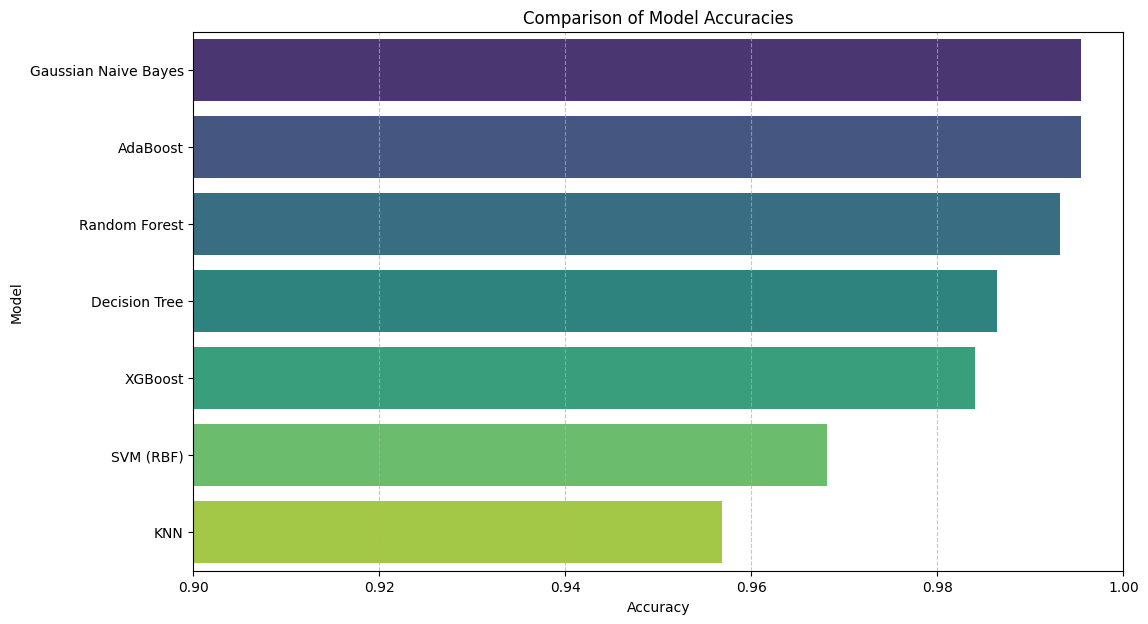

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collected accuracy scores for each model
model_accuracies = {
    'KNN': 0.9568181818181818,
    'Gaussian Naive Bayes': 0.9954545454545455,
    'Decision Tree': 0.9863636363636363,
    'SVM (RBF)': 0.9681818181818181,
    'Random Forest': 0.9931818181818182,
    'XGBoost': 0.9840909090909091,
    'AdaBoost': 0.9954545454545455
}

# Create a DataFrame for easy plotting
accuracy_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])

# Sort by accuracy for better visualization
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0.9, 1.0) # Set x-axis limit to highlight differences
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Exporting Models with Pickle

This cell exports the trained `AdaBoost` and `Gaussian Naive Bayes` models to `.pkl` files using Python's `pickle` module. This allows you to save the trained models to disk and later load them for making predictions without retraining.

In [19]:
import pickle
with open("ada_model.pkl","wb") as file:
  pickle.dump(ada,file)
with open("nb_model.pkl","wb") as file:
  pickle.dump(nb,file)
